In [1]:
# 1. mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Results from **train_models.py** <br>

Models were trained locally using an NVIDIA GeForce RTX 4060 GPU. <br>
Training time: around 13 hours. <br>

### Model Variants Description

| Model            | Description                                                       |
|----------------------|-------------------------------------------------------------------|
| ResNet50-Direct      | trained directly on TCGA-BRCA A2                                  |
| ResNet50-TS          | two step transfer learning: BreakHis then TCGA-BRCA A2           |
| ResNet50-SSL         | self supervised SimCLR pretrain then TCGA-BRCA A2                |
| EfficientNet-Direct  | trained directly on TCGA-BRCA A2                                  |
| EfficientNet-TS      | two step transfer learning: BreakHis then TCGA-BRCA A2           |

In [ ]:
# 2. train_models.py
import os
import json
import shutil
import pandas as pd

models_img = '/content/drive/MyDrive/ONCO-PROBE/models_v2/image_classifier'

# rename model files to clear names
rename_map = {
    'resnet50_imagenet_best.pth': 'resnet50_direct_best.pth',
    'resnet50_bh_best.pth': 'resnet50_ts_best.pth',
    'resnet50_simclr_best.pth': 'resnet50_ssl_best.pth',
    'efficientnet_imagenet_best.pth': 'efficientnet_direct_best.pth',
    'efficientnet_bh_best.pth': 'efficientnet_ts_best.pth',
}

for old_name, new_name in rename_map.items():
    old_path = os.path.join(models_img, old_name)
    new_path = os.path.join(models_img, new_name)
    if os.path.exists(old_path):
        shutil.copy(old_path, new_path)
        print(f"renamed {old_name} to {new_name}")
    else:
        print(f"not found {old_name}")

# load and display results
results_path = os.path.join(models_img, 'training_results.json')
with open(results_path, 'r') as f:
    results = json.load(f)

rename_results = {
    'resnet50_imagenet': 'ResNet50-Direct',
    'resnet50_breakhis_pretrain': 'ResNet50-TS',
    'resnet50_simclr': 'ResNet50-SSL',
    'efficientnet_imagenet': 'EfficientNet-Direct',
    'efficientnet_breakhis_pretrain': 'EfficientNet-TS',
}

rows = []
for old_key, new_key in rename_results.items():
    if old_key in results:
        res = results[old_key]
        rows.append({
            'model': new_key,
            'slide_auc': res['slide_auc'],
            'tile_auc': res['tile_auc'],
            'accuracy_optimal': res['accuracy_optimal'],
            'f1_tnbc_optimal': res['f1_tnbc_optimal'],
            'accuracy_default': res['accuracy_default'],
            'f1_tnbc_default': res['f1_tnbc_default'],
            'optimal_threshold': res['optimal_threshold'],
            'n_test_patients': res['n_test_patients'],
            'n_tnbc_test': res['n_tnbc_test']
        })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values('slide_auc', ascending=False).reset_index(drop=True)

print()
print("image classifier results")
print()
print(df_results.to_string(index=False))

renamed resnet50_imagenet_best.pth to resnet50_direct_best.pth
renamed resnet50_bh_best.pth to resnet50_ts_best.pth
renamed resnet50_simclr_best.pth to resnet50_ssl_best.pth
renamed efficientnet_imagenet_best.pth to efficientnet_direct_best.pth
renamed efficientnet_bh_best.pth to efficientnet_ts_best.pth

image classifier results

              model  slide_auc  tile_auc  accuracy_optimal  f1_tnbc_optimal  accuracy_default  f1_tnbc_default  optimal_threshold  n_test_patients  n_tnbc_test
        ResNet50-TS     0.9259    0.7677            0.9524           0.8000            0.8571              0.0             0.3776               21            3
    EfficientNet-TS     0.9259    0.7724            0.8571           0.6667            0.8571              0.0             0.2253               21            3
    ResNet50-Direct     0.9074    0.7395            0.9048           0.6667            0.8571              0.0             0.1826               21            3
       ResNet50-SSL     0.9

In [ ]:
# 2a. check what is saved in training results
import json

with open(f'{models_img}/training_results.json', 'r') as f:
    results = json.load(f)

for model_name, res in results.items():
    print(model_name)
    print(list(res.keys()))
    print()

resnet50_imagenet
['model', 'tile_auc', 'slide_auc', 'optimal_threshold', 'n_test_patients', 'n_tnbc_test', 'accuracy_default', 'accuracy_optimal', 'f1_tnbc_default', 'f1_tnbc_optimal']

resnet50_breakhis_pretrain
['model', 'tile_auc', 'slide_auc', 'optimal_threshold', 'n_test_patients', 'n_tnbc_test', 'accuracy_default', 'accuracy_optimal', 'f1_tnbc_default', 'f1_tnbc_optimal']

resnet50_simclr
['model', 'tile_auc', 'slide_auc', 'optimal_threshold', 'n_test_patients', 'n_tnbc_test', 'accuracy_default', 'accuracy_optimal', 'f1_tnbc_default', 'f1_tnbc_optimal']

efficientnet_imagenet
['model', 'tile_auc', 'slide_auc', 'optimal_threshold', 'n_test_patients', 'n_tnbc_test', 'accuracy_default', 'accuracy_optimal', 'f1_tnbc_default', 'f1_tnbc_optimal']

efficientnet_breakhis_pretrain
['model', 'tile_auc', 'slide_auc', 'optimal_threshold', 'n_test_patients', 'n_tnbc_test', 'accuracy_default', 'accuracy_optimal', 'f1_tnbc_default', 'f1_tnbc_optimal']



In [ ]:
# 3. paths
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

drive_base = '/content/drive/MyDrive/ONCO-PROBE'
processed = f'{drive_base}/results_v2/processed'
figures = f'{drive_base}/results_v2/figures'
models_img = f'{drive_base}/models_v2/image_classifier'
models_gene = f'{drive_base}/models_v2/gene_classifier'

os.makedirs(figures, exist_ok=True)
os.makedirs(models_gene, exist_ok=True)

print("paths set")
print("processed", processed)
print("figures", figures)
print("models gene", models_gene)

paths set
processed /content/drive/MyDrive/ONCO-PROBE/results_v2/processed
figures /content/drive/MyDrive/ONCO-PROBE/results_v2/figures
models gene /content/drive/MyDrive/ONCO-PROBE/models_v2/gene_classifier


In [ ]:
# check column names
print("last 10 columns of gene labeled")
print(list(gene_labeled.columns[-10:]))
print()
print("first 5 columns")
print(list(gene_labeled.columns[:5]))

last 10 columns of gene labeled
['GSM2202904', 'GSM2202905', 'GSM2202906', 'GSM2202907', 'GSM2202908', 'GSM2202909', 'GSM2202910', 'GSM2202911', 'GSM2202912', 'GSM2202913']

first 5 columns
['TCGA-A2-A0YM-01', 'TCGA-A2-A25C-01', 'TCGA-A2-A1FV-01', 'TCGA-A2-A0YI-01', 'TCGA-A2-A04N-01']


In [ ]:
# check gene labels file
gene_labels = pd.read_csv(f'{processed}/gene_labels_all.csv', index_col=0)
print("gene labels shape", gene_labels.shape)
print("columns", list(gene_labels.columns))
print("first few rows")
print(gene_labels.head())

gene labels shape (538, 1)
columns ['TNBC']
first few rows
                 TNBC
sample_id            
TCGA-A2-A04N-01     0
TCGA-A2-A04P-01     0
TCGA-A2-A04Q-01     0
TCGA-A2-A04R-01     0
TCGA-A2-A04T-01     0


In [ ]:
# 4. load gene data — tcga matched patients only
gene_df = pd.read_csv(f'{processed}/gene_matched.csv', index_col=0)
clini = pd.read_csv(f'{processed}/clinical_a2_matched.csv')

print("gene matrix shape", gene_df.shape)
print("clinical shape", clini.shape)

gene matrix shape (20530, 102)
clinical shape (102, 204)


In [ ]:
# 5. prepare labels
clini_indexed = clini.set_index('Sample ID')
common = gene_df.columns.intersection(clini_indexed.index)

X = gene_df[common].T
y = clini_indexed.loc[common, 'TNBC']

print("gene data shape", X.shape)
print("labels shape", y.shape)
print("tnbc patients", y.sum())
print("non-tnbc patients", (y == 0).sum())

gene data shape (102, 20530)
labels shape (102,)
tnbc patients 12
non-tnbc patients 90


In [ ]:
# 6. select top 2000 variable genes and scale
from sklearn.preprocessing import StandardScaler

gene_var = X.var(axis=0)
top_idx = np.argsort(gene_var)[-2000:]
X_top = X.iloc[:, top_idx]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top.values)
y_arr = y.values.astype(int)

print("X shape after selection", X_top.shape)
print("tnbc", (y_arr == 1).sum())
print("non-tnbc", (y_arr == 0).sum())

X shape after selection (102, 2000)
tnbc 12
non-tnbc 90


In [ ]:
# 7. train gene classifiers 5 fold stratified cross validation
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import pickle
import joblib

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# random forest
print("training random forest")
rf_aucs = []
rf_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr)):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_arr[train_idx], y_arr[val_idx]

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    probs = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, probs)
    rf_aucs.append(auc)
    rf_models.append(rf)
    print(f"fold {fold+1} auc {round(auc, 4)}")

print(f"rf mean auc {round(np.mean(rf_aucs), 4)} std {round(np.std(rf_aucs), 4)}")

# xgboost
print()
print("training xgboost")
xgb_aucs = []
xgb_models = []

scale_pos_weight = (y_arr == 0).sum() / (y_arr == 1).sum()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr)):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_arr[train_idx], y_arr[val_idx]

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.3,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    probs = xgb.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, probs)
    xgb_aucs.append(auc)
    xgb_models.append(xgb)
    print(f"fold {fold+1} auc {round(auc, 4)}")

print(f"xgb mean auc {round(np.mean(xgb_aucs), 4)} std {round(np.std(xgb_aucs), 4)}")

# save best models
best_rf = rf_models[np.argmax(rf_aucs)]
best_xgb = xgb_models[np.argmax(xgb_aucs)]

with open(f'{models_gene}/random_forest_best.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

with open(f'{models_gene}/xgboost_best.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

joblib.dump(scaler, f'{models_gene}/gene_scaler.pkl')
np.save(f'{models_gene}/top_gene_indices.npy', top_idx)
np.save(f'{models_gene}/top_gene_names.npy', X_top.columns.values)

print()
print("models saved")
print(f"rf mean auc {round(np.mean(rf_aucs), 4)}")
print(f"xgb mean auc {round(np.mean(xgb_aucs), 4)}")

training random forest
fold 1 auc 0.963
fold 2 auc 0.7778
fold 3 auc 0.8889
fold 4 auc 0.9444
fold 5 auc 0.9444
rf mean auc 0.9037 std 0.0677

training xgboost
fold 1 auc 0.963
fold 2 auc 0.8148
fold 3 auc 0.8611
fold 4 auc 0.9444
fold 5 auc 0.8889
xgb mean auc 0.8944 std 0.0542

models saved
rf mean auc 0.9037
xgb mean auc 0.8944


In [ ]:
# 8. gene feature importance
gene_names = X_top.columns.values

# random forest importance
rf_importance = best_rf.feature_importances_
rf_top_idx = np.argsort(rf_importance)[-20:][::-1]
rf_top_genes = gene_names[rf_top_idx]
rf_top_scores = rf_importance[rf_top_idx]

print("top 20 genes by random forest importance")
for gene, score in zip(rf_top_genes, rf_top_scores):
    print(f"{gene} {round(score, 4)}")

print()

# xgboost importance
xgb_importance = best_xgb.feature_importances_
xgb_top_idx = np.argsort(xgb_importance)[-20:][::-1]
xgb_top_genes = gene_names[xgb_top_idx]
xgb_top_scores = xgb_importance[xgb_top_idx]

print("top 20 genes by xgboost importance")
for gene, score in zip(xgb_top_genes, xgb_top_scores):
    print(f"{gene} {round(score, 4)}")

# save gene importance
np.save(f'{models_gene}/rf_top_genes.npy', rf_top_genes)
np.save(f'{models_gene}/xgb_top_genes.npy', xgb_top_genes)
print()
print("gene importance saved")

top 20 genes by random forest importance
TMEM45B 0.0211
GPRC5A 0.0195
PRR15 0.0174
OLAH 0.0147
ROPN1 0.0145
TFF3 0.014
ERBB4 0.0138
MAPK4 0.013
SIDT1 0.013
KCNH1 0.0118
SRMS 0.0118
CRHR1 0.0116
FOXC1 0.0114
SOX8 0.0114
EFNA5 0.0112
REEP1 0.0109
HORMAD1 0.009
RGMA 0.0089
SYTL5 0.0087
NAT1 0.0086

top 20 genes by xgboost importance
PDZK1 0.08089999854564667
ROPN1 0.07419999688863754
FOXC1 0.052799999713897705
UGT8 0.052799999713897705
CA12 0.05180000141263008
BCAS1 0.04490000009536743
ABCA13 0.039000000804662704
KRT6B 0.03709999844431877
KCNJ11 0.03460000082850456
KRT81 0.026200000196695328
RGMA 0.025599999353289604
PROM1 0.024700000882148743
FAM19A3 0.02459999918937683
BBOX1 0.024299999698996544
SORBS2 0.019700000062584877
EFNA5 0.019300000742077827
KRT83 0.019099999219179153
MAPK4 0.018400000408291817
ZIC5 0.013899999670684338
CECR2 0.01360000018030405

gene importance saved


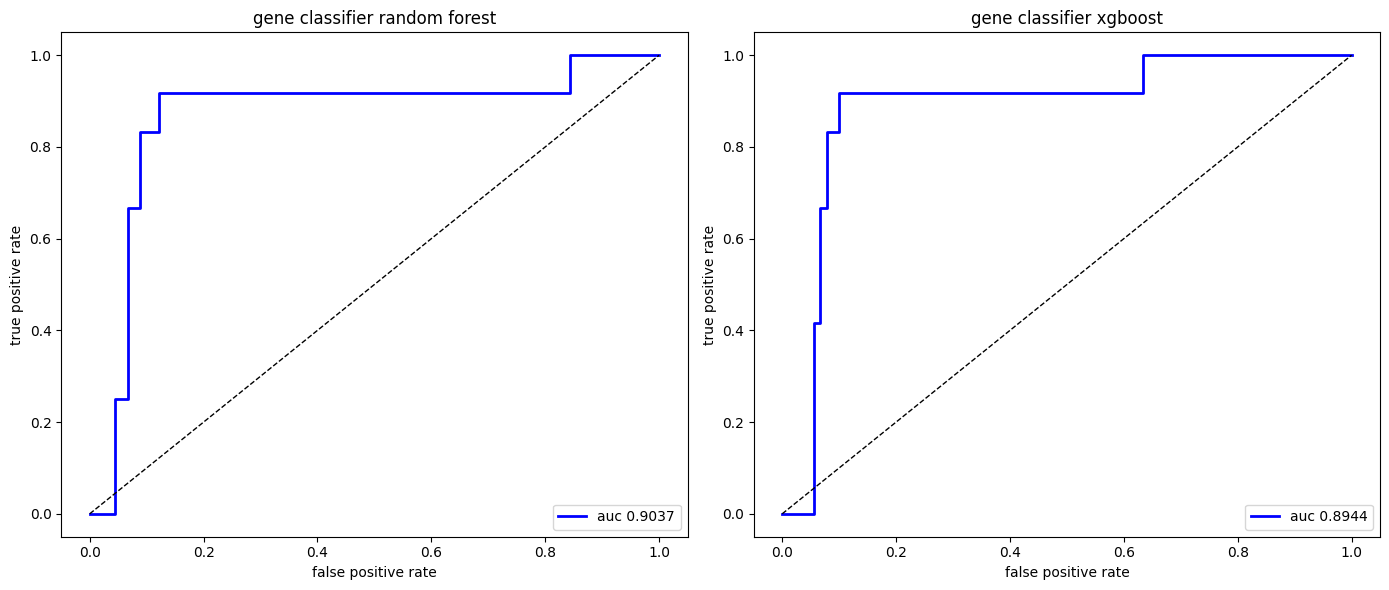

gene roc curves saved


In [ ]:
# 9. plot roc curves for gene classifiers
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model, model_name, aucs) in zip(axes, [
    (best_rf, 'random forest', rf_aucs),
    (best_xgb, 'xgboost', xgb_aucs)
]):
    all_probs = []
    all_labels = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr)):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        if model_name == 'random forest':
            m = RandomForestClassifier(
                n_estimators=300, max_depth=5,
                min_samples_leaf=3, class_weight='balanced',
                random_state=42, n_jobs=-1
            )
        else:
            m = XGBClassifier(
                n_estimators=200, max_depth=3,
                learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.3,
                scale_pos_weight=scale_pos_weight,
                random_state=42, eval_metric='auc', verbosity=0
            )

        m.fit(X_train, y_train)
        probs = m.predict_proba(X_val)[:, 1]
        all_probs.extend(probs)
        all_labels.extend(y_val)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    mean_auc = np.mean(aucs)
    ax.plot(fpr, tpr, color='blue', lw=2,
            label=f'auc {round(mean_auc, 4)}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('false positive rate')
    ax.set_ylabel('true positive rate')
    ax.set_title(f'gene classifier {model_name}')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{figures}/gene_classifier_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("gene roc curves saved")

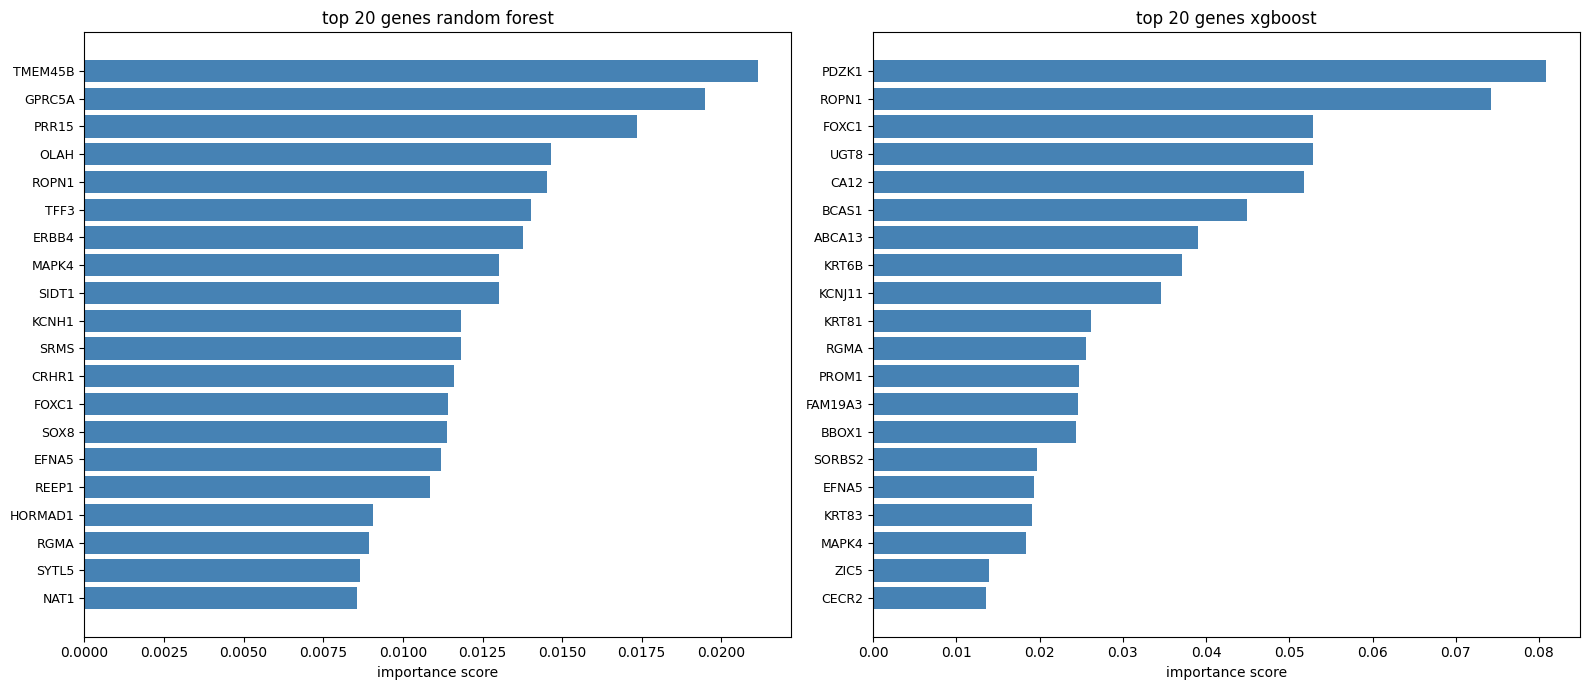

gene feature importance saved


In [ ]:
# 10. plot feature importance top 20 genes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (model_name, top_genes, top_scores) in zip(axes, [
    ('random forest', rf_top_genes, rf_top_scores),
    ('xgboost', xgb_top_genes, xgb_top_scores)
]):
    ax.barh(range(20), top_scores[::-1], color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_genes[::-1], fontsize=9)
    ax.set_xlabel('importance score')
    ax.set_title(f'top 20 genes {model_name}')

plt.tight_layout()
plt.savefig(f'{figures}/gene_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("gene feature importance saved")

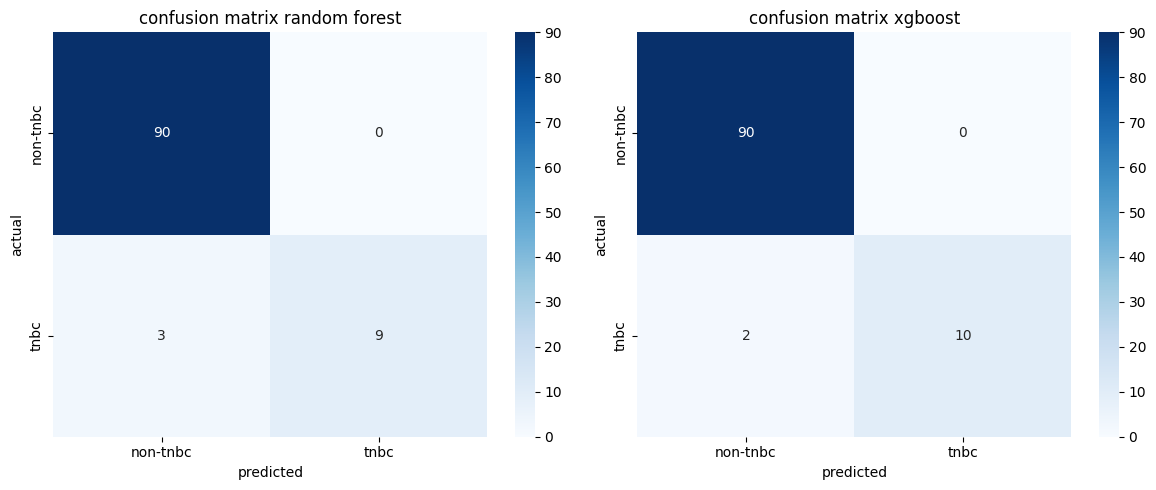

gene confusion matrix saved


In [ ]:
# 11. confusion matrix for both gene classifiers
from sklearn.metrics import confusion_matrix
import itertools

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model_name, model) in zip(axes, [
    ('random forest', best_rf),
    ('xgboost', best_xgb)
]):
    all_preds = []
    all_labels = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr)):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]
        preds = model.predict(X_val)
        all_preds.extend(preds)
        all_labels.extend(y_val)

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['non-tnbc', 'tnbc'],
                yticklabels=['non-tnbc', 'tnbc'])
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
    ax.set_title(f'confusion matrix {model_name}')

plt.tight_layout()
plt.savefig(f'{figures}/gene_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("gene confusion matrix saved")

In [ ]:
# 12. gene classifier summary
print("gene classifier summary")
print()
print(f"random forest mean auc {round(np.mean(rf_aucs), 4)} std {round(np.std(rf_aucs), 4)}")
print(f"xgboost mean auc {round(np.mean(xgb_aucs), 4)} std {round(np.std(xgb_aucs), 4)}")
print()

# per fold results
print("per fold auc")
print(f"{'fold':<10} {'random forest':<20} {'xgboost':<20}")
for i, (rf_auc, xgb_auc) in enumerate(zip(rf_aucs, xgb_aucs)):
    print(f"{i+1:<10} {round(rf_auc, 4):<20} {round(xgb_auc, 4):<20}")

print()
print("top 5 genes random forest")
for gene, score in zip(rf_top_genes[:5], rf_top_scores[:5]):
    print(f"  {gene} {round(score, 4)}")

print()
print("top 5 genes xgboost")
for gene, score in zip(xgb_top_genes[:5], xgb_top_scores[:5]):
    print(f"  {gene} {round(score, 4)}")

print()
print("gene classifier notebook complete")

gene classifier summary

random forest mean auc 0.9037 std 0.0677
xgboost mean auc 0.8944 std 0.0542

per fold auc
fold       random forest        xgboost             
1          0.963                0.963               
2          0.7778               0.8148              
3          0.8889               0.8611              
4          0.9444               0.9444              
5          0.9444               0.8889              

top 5 genes random forest
  TMEM45B 0.0211
  GPRC5A 0.0195
  PRR15 0.0174
  OLAH 0.0147
  ROPN1 0.0145

top 5 genes xgboost
  PDZK1 0.08089999854564667
  ROPN1 0.07419999688863754
  FOXC1 0.052799999713897705
  UGT8 0.052799999713897705
  CA12 0.05180000141263008

gene classifier notebook complete


image classifier results
              model  slide_auc  tile_auc  accuracy_optimal  f1_tnbc_optimal
        ResNet50-TS     0.9259    0.7677            0.9524           0.8000
    EfficientNet-TS     0.9259    0.7724            0.8571           0.6667
    ResNet50-Direct     0.9074    0.7395            0.9048           0.6667
       ResNet50-SSL     0.9074    0.7578            0.9524           0.8000
EfficientNet-Direct     0.8704    0.7197            0.9048           0.6667


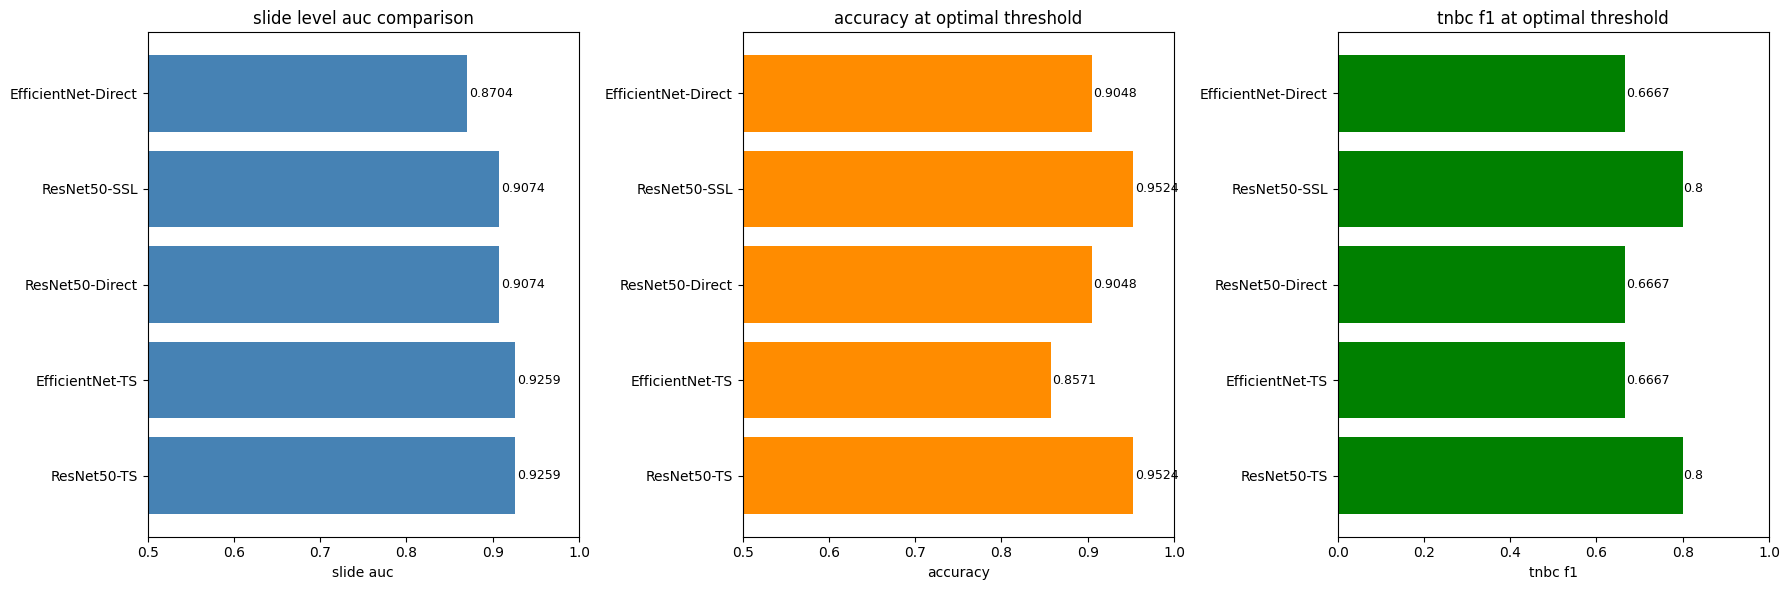

image classifier comparison saved


In [ ]:
# 13. image classifier results and plots
import json

with open(f'{models_img}/training_results.json', 'r') as f:
    img_results = json.load(f)

rename_map = {
    'resnet50_imagenet': 'ResNet50-Direct',
    'resnet50_breakhis_pretrain': 'ResNet50-TS',
    'resnet50_simclr': 'ResNet50-SSL',
    'efficientnet_imagenet': 'EfficientNet-Direct',
    'efficientnet_breakhis_pretrain': 'EfficientNet-TS',
}

rows = []
for old_key, new_key in rename_map.items():
    if old_key in img_results:
        res = img_results[old_key]
        rows.append({
            'model': new_key,
            'slide_auc': res['slide_auc'],
            'tile_auc': res['tile_auc'],
            'accuracy_optimal': res['accuracy_optimal'],
            'f1_tnbc_optimal': res['f1_tnbc_optimal'],
        })

df_img = pd.DataFrame(rows).sort_values('slide_auc', ascending=False).reset_index(drop=True)
print("image classifier results")
print(df_img.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(df_img['model'], df_img['slide_auc'], color='steelblue')
axes[0].set_xlabel('slide auc')
axes[0].set_title('slide level auc comparison')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(df_img['slide_auc']):
    axes[0].text(v + 0.002, i, str(round(v, 4)), va='center', fontsize=9)

axes[1].barh(df_img['model'], df_img['accuracy_optimal'], color='darkorange')
axes[1].set_xlabel('accuracy')
axes[1].set_title('accuracy at optimal threshold')
axes[1].set_xlim(0.5, 1.0)
for i, v in enumerate(df_img['accuracy_optimal']):
    axes[1].text(v + 0.002, i, str(round(v, 4)), va='center', fontsize=9)

axes[2].barh(df_img['model'], df_img['f1_tnbc_optimal'], color='green')
axes[2].set_xlabel('tnbc f1')
axes[2].set_title('tnbc f1 at optimal threshold')
axes[2].set_xlim(0, 1.0)
for i, v in enumerate(df_img['f1_tnbc_optimal']):
    axes[2].text(v + 0.002, i, str(round(v, 4)), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{figures}/image_classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("image classifier comparison saved")

In [ ]:
# 16. full summary table all models image and gene
print("full results summary")
print()
print("image classifiers")
print(f"{'model':<25} {'slide auc':<12} {'tile auc':<12} {'accuracy':<12} {'f1 tnbc':<12}")
for model_name, res in img_results.items():
    name_map = {
        'resnet50_imagenet': 'ResNet50-Direct',
        'resnet50_breakhis_pretrain': 'ResNet50-TS',
        'resnet50_simclr': 'ResNet50-SSL',
        'efficientnet_imagenet': 'EfficientNet-Direct',
        'efficientnet_breakhis_pretrain': 'EfficientNet-TS'
    }
    name = name_map.get(model_name, model_name)
    print(f"{name:<25} {res['slide_auc']:<12} {res['tile_auc']:<12} {res['accuracy_optimal']:<12} {res['f1_tnbc_optimal']:<12}")

print()
print("gene classifiers")
print(f"{'model':<25} {'mean auc':<12} {'std':<12}")
print(f"{'random forest':<25} {round(np.mean(rf_aucs), 4):<12} {round(np.std(rf_aucs), 4):<12}")
print(f"{'xgboost':<25} {round(np.mean(xgb_aucs), 4):<12} {round(np.std(xgb_aucs), 4):<12}")

print()
print("notebook 2 complete")

full results summary

image classifiers
model                     slide auc    tile auc     accuracy     f1 tnbc     
ResNet50-Direct           0.9074       0.7395       0.9048       0.6667      
ResNet50-TS               0.9259       0.7677       0.9524       0.8         
ResNet50-SSL              0.9074       0.7578       0.9524       0.8         
EfficientNet-Direct       0.8704       0.7197       0.9048       0.6667      
EfficientNet-TS           0.9259       0.7724       0.8571       0.6667      

gene classifiers
model                     mean auc     std         
random forest             0.9037       0.0677      
xgboost                   0.8944       0.0542      

notebook 2 complete


In [19]:
# 17a. download METABRIC clinical data
import requests
import pandas as pd
import os

base_api     = 'https://www.cbioportal.org/api'
study_id     = 'brca_metabric'
data_dir     = '/content/drive/MyDrive/ONCO-PROBE/data'
metabric_dir = os.path.join(data_dir, 'metabric')
os.makedirs(metabric_dir, exist_ok=True)

# fetch all clinical data (two pages covers all ~2000 patients)
all_data = []
for page in range(3):
    r = requests.get(
        f'{base_api}/studies/{study_id}/clinical-data',
        params={'clinicalDataType': 'PATIENT', 'pageSize': 10000, 'pageNumber': page}
    )
    chunk = r.json()
    if not chunk:
        break
    all_data.extend(chunk)
    print(f"page {page}: {len(chunk)} records")

print(f"total records: {len(all_data)}")

clinical_df   = pd.DataFrame(all_data)
clinical_wide = clinical_df.pivot_table(
    index='patientId', columns='clinicalAttributeId',
    values='value', aggfunc='first'
).reset_index()

print(f"patients: {len(clinical_wide)}")
print("columns:", list(clinical_wide.columns[:15]))

clinical_wide.to_csv(f'{metabric_dir}/clinical_wide_all.csv', index=False)
print("saved clinical_wide_all.csv")

page 0: 10000 records
page 1: 10000 records
page 2: 10000 records
total records: 30000
patients: 1269
columns: ['patientId', 'AGE_AT_DIAGNOSIS', 'BREAST_SURGERY', 'CELLULARITY', 'CHEMOTHERAPY', 'CLAUDIN_SUBTYPE', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HISTOLOGICAL_SUBTYPE', 'HORMONE_THERAPY', 'INFERRED_MENOPAUSAL_STATE', 'INTCLUST', 'LATERALITY', 'LYMPH_NODES_EXAMINED_POSITIVE']
saved clinical_wide_all.csv


In [20]:
# 17b. check TNBC column values
import pandas as pd
import os

metabric_dir  = '/content/drive/MyDrive/ONCO-PROBE/data/metabric'
clinical_wide = pd.read_csv(f'{metabric_dir}/clinical_wide_all.csv')

print("CLAUDIN_SUBTYPE values:")
print(clinical_wide['CLAUDIN_SUBTYPE'].value_counts())
print()
print("ER_IHC values:")
print(clinical_wide['ER_IHC'].value_counts())

CLAUDIN_SUBTYPE values:
CLAUDIN_SUBTYPE
LumA           467
LumB           294
claudin-low    159
Her2           132
Basal          113
Normal          97
NC               3
Name: count, dtype: int64

ER_IHC values:
ER_IHC
Positve     977
Negative    257
Name: count, dtype: int64


In [21]:
# 17c. identify TNBC patients
tnbc_mask     = clinical_wide['CLAUDIN_SUBTYPE'].isin(['Basal', 'claudin-low'])
er_neg        = clinical_wide['ER_IHC'].str.strip() == 'Negative'
tnbc_patients = clinical_wide[tnbc_mask & er_neg]
tnbc_pids     = tnbc_patients['patientId'].tolist()

luma_patients = clinical_wide[
    (clinical_wide['CLAUDIN_SUBTYPE'] == 'LumA') &
    (clinical_wide['ER_IHC'].str.strip() == 'Positve')  # typo in data
]
ctrl_pids = luma_patients['patientId'].tolist()

print(f"TNBC patients (Basal/claudin-low + ER-): {len(tnbc_pids)}")
print(f"Control patients (LumA + ER+):           {len(ctrl_pids)}")
print()
print("TNBC subtype breakdown:")
print(tnbc_patients['CLAUDIN_SUBTYPE'].value_counts())

TNBC patients (Basal/claudin-low + ER-): 155
Control patients (LumA + ER+):           452

TNBC subtype breakdown:
CLAUDIN_SUBTYPE
Basal          92
claudin-low    63
Name: count, dtype: int64


In [22]:
# 17d. find correct mRNA profile
import requests

base_api = 'https://www.cbioportal.org/api'
study_id = 'brca_metabric'

r = requests.get(f'{base_api}/studies/{study_id}/molecular-profiles')
print("status:", r.status_code)
for p in r.json():
    print(p['molecularProfileId'], '|', p['datatype'], '|', p['name'])

status: 200
brca_metabric_cna | DISCRETE | Putative copy-number alterations from DNAcopy.
brca_metabric_methylation_promoters_rrbs | CONTINUOUS | Promoter methylation (RRBS)
brca_metabric_mrna | CONTINUOUS | mRNA expression (Illumina HT-12 v3 microarray)
brca_metabric_mrna_median_all_sample_Zscores | Z-SCORE | mRNA expression z-scores relative to all samples (log microarray)
brca_metabric_mutations | MAF | Mutations


In [23]:
# 17e. get sample IDs for TNBC and control patients
import numpy as np

mrna_profile = 'brca_metabric_mrna_median_all_sample_Zscores'

r         = requests.get(f'{base_api}/studies/{study_id}/samples', params={'pageSize': 10000})
sample_df = pd.DataFrame(r.json())
print(f"total samples in study: {len(sample_df)}")
print(f"sample ID example: {sample_df['sampleId'].iloc[0]}")
print(f"patient ID example: {sample_df['patientId'].iloc[0]}")

tnbc_sids = sample_df[sample_df['patientId'].isin(tnbc_pids)]['sampleId'].tolist()
ctrl_sids = sample_df[sample_df['patientId'].isin(ctrl_pids)]['sampleId'].tolist()

np.random.seed(42)
ctrl_sids = np.random.choice(ctrl_sids, size=len(tnbc_sids), replace=False).tolist()

print(f"\nTNBC sample IDs found:   {len(tnbc_sids)}")
print(f"control sample IDs used: {len(ctrl_sids)}")

total samples in study: 2509
sample ID example: MB-0000
patient ID example: MB-0000

TNBC sample IDs found:   155
control sample IDs used: 155


In [26]:
# fix fetch endpoint
def fetch_expr(sample_ids, profile_id, batch_size=50):
    all_records = []
    for i in range(0, len(sample_ids), batch_size):
        batch   = sample_ids[i:i+batch_size]
        payload = {"sampleIds": batch, "entrezGeneIds": []}
        r       = requests.post(
            f'{base_api}/molecular-profiles/{profile_id}/molecular-data/fetch',
            json=payload, params={"projection": "SUMMARY"}
        )
        if r.status_code == 200:
            all_records.extend(r.json())
            print(f"  batch {i//batch_size+1}: {len(r.json())} records")
        else:
            print(f"  batch {i//batch_size+1}: HTTP {r.status_code} — {r.text[:200]}")
    return all_records

print("test — first batch TNBC...")
test = fetch_expr(tnbc_sids[:50], mrna_profile)
print(f"records: {len(test)}")
if test:
    print("example record:", test[0])

test — first batch TNBC...
  batch 1: HTTP 400 — {"message":"entrezGeneIds size must be between 1 and 10000000"}
records: 0


In [27]:
# get entrez IDs for our 2000 genes
import numpy as np
top_gene_names = np.load('/content/drive/MyDrive/ONCO-PROBE/models_v2/gene_classifier/top_gene_names.npy', allow_pickle=True)

r = requests.post(
    f'{base_api}/genes/fetch',
    json=list(top_gene_names),
    params={"geneIdType": "HUGO_GENE_SYMBOL"}
)
print("status:", r.status_code)
genes = r.json()
print("genes returned:", len(genes))
print("example:", genes[0])

status: 200
genes returned: 1781
example: {'entrezGeneId': 144568, 'hugoGeneSymbol': 'A2ML1', 'type': 'protein-coding'}


In [28]:
# 18. fetch expression with entrez IDs
entrez_ids = [g['entrezGeneId'] for g in genes]

def fetch_expr(sample_ids, profile_id, entrez_ids, batch_size=50):
    all_records = []
    for i in range(0, len(sample_ids), batch_size):
        batch   = sample_ids[i:i+batch_size]
        payload = {"sampleIds": batch, "entrezGeneIds": entrez_ids}
        r       = requests.post(
            f'{base_api}/molecular-profiles/{profile_id}/molecular-data/fetch',
            json=payload, params={"projection": "SUMMARY"}
        )
        if r.status_code == 200:
            all_records.extend(r.json())
            print(f"  batch {i//batch_size+1}: {len(r.json())} records")
        else:
            print(f"  batch {i//batch_size+1}: HTTP {r.status_code} — {r.text[:200]}")
    return all_records

print("downloading TNBC expression...")
tnbc_records = fetch_expr(tnbc_sids, mrna_profile, entrez_ids)
print(f"total: {len(tnbc_records)}")
if tnbc_records:
    print("example:", tnbc_records[0])

downloading TNBC expression...
  batch 1: 86800 records
  batch 2: 86800 records
  batch 3: 86800 records
  batch 4: 8680 records
total: 269080
example: {'uniqueSampleKey': 'TUItMDA0NTpicmNhX21ldGFicmlj', 'uniquePatientKey': 'TUItMDA0NTpicmNhX21ldGFicmlj', 'entrezGeneId': 4986, 'molecularProfileId': 'brca_metabric_mrna_median_all_sample_Zscores', 'sampleId': 'MB-0045', 'patientId': 'MB-0045', 'studyId': 'brca_metabric', 'value': 0.0686}


In [30]:
# 19. download control expression, apply classifiers, save results
import pickle, joblib
from sklearn.metrics import roc_auc_score, classification_report

models_gene = '/content/drive/MyDrive/ONCO-PROBE/models_v2/gene_classifier'

print("downloading control expression...")
ctrl_records = fetch_expr(ctrl_sids, mrna_profile, entrez_ids)
print(f"total: {len(ctrl_records)}")

# pivot to patients x genes
entrez_to_hugo = {g['entrezGeneId']: g['hugoGeneSymbol'] for g in genes}

def to_matrix(records):
    df    = pd.DataFrame(records)
    pivot = df.pivot_table(index='patientId', columns='entrezGeneId',
                           values='value', aggfunc='first')
    pivot.columns = [entrez_to_hugo.get(c, c) for c in pivot.columns]
    return pivot

tnbc_mat = to_matrix(tnbc_records)
ctrl_mat = to_matrix(ctrl_records)
print(f"\nTNBC matrix:    {tnbc_mat.shape}")
print(f"control matrix: {ctrl_mat.shape}")

# align to TCGA model genes
top_gene_names = np.load(f'{models_gene}/top_gene_names.npy', allow_pickle=True)
gene_scaler    = joblib.load(f'{models_gene}/gene_scaler.pkl')
with open(f'{models_gene}/random_forest_best.pkl', 'rb') as f:
    rf_model  = pickle.load(f)
with open(f'{models_gene}/xgboost_best.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

def align(mat, genes):
    out     = pd.DataFrame(0.0, index=mat.index, columns=genes)
    overlap = [g for g in genes if g in mat.columns]
    out[overlap] = mat[overlap]
    print(f"  gene overlap: {len(overlap)} / {len(genes)}")
    return out

print("\naligning genes...")
tnbc_aligned = align(tnbc_mat, top_gene_names)
ctrl_aligned = align(ctrl_mat, top_gene_names)

X = np.vstack([gene_scaler.transform(tnbc_aligned.values),
               gene_scaler.transform(ctrl_aligned.values)])
y = np.array([1]*len(tnbc_aligned) + [0]*len(ctrl_aligned))

rf_probs  = rf_model.predict_proba(X)[:, 1]
xgb_probs = xgb_model.predict_proba(X)[:, 1]

rf_auc  = roc_auc_score(y, rf_probs)
xgb_auc = roc_auc_score(y, xgb_probs)

print("\n── METABRIC external validation (TNBC vs LumA ER+) ──")
print(f"patients: {len(y)}  ({y.sum()} TNBC / {(y==0).sum()} control)")
print(f"Random Forest AUC:  {rf_auc:.4f}")
print(f"XGBoost AUC:        {xgb_auc:.4f}")
print()
print(classification_report(y, (rf_probs>=0.5).astype(int),
      target_names=['control','tnbc'], zero_division=0))

results = pd.DataFrame({
    'patientId': list(tnbc_aligned.index) + list(ctrl_aligned.index),
    'label':     list(y),
    'rf_prob':   rf_probs,
    'xgb_prob':  xgb_probs,
})
results.to_csv(f'{metabric_dir}/metabric_validation_results.csv', index=False)
print("saved metabric_validation_results.csv")

downloading control expression...
  batch 1: 86800 records
  batch 2: 86800 records
  batch 3: 86800 records
  batch 4: 8680 records
total: 269080

TNBC matrix:    (155, 1736)
control matrix: (155, 1736)

aligning genes...
  gene overlap: 1736 / 2000
  gene overlap: 1736 / 2000

── METABRIC external validation (TNBC vs LumA ER+) ──
patients: 310  (155 TNBC / 155 control)
Random Forest AUC:  0.7396
XGBoost AUC:        0.6850

              precision    recall  f1-score   support

     control       0.50      1.00      0.67       155
        tnbc       0.00      0.00      0.00       155

    accuracy                           0.50       310
   macro avg       0.25      0.50      0.33       310
weighted avg       0.25      0.50      0.33       310

saved metabric_validation_results.csv
